In [4]:
import os
from typing import Annotated,List,TypedDict,Literal
from langchain_core.messages import BaseMessage,HumanMessage,AIMessage,ToolMessage,SystemMessage
from langchain_groq import ChatGroq
from langchain.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph,START,END,MessagesState
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from dotenv import load_dotenv

In [17]:
load_dotenv()

True

In [18]:
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [19]:
class AgentState(MessagesState):
    next_agent: str # Which agent will go next



In [20]:
@tool 
def search_web(query:str):
    """
    Searches the web
    """
    
    search = TavilySearchResults(max_results=3)
    res = search.invoke(query)
    return str(res)

@tool
def write_summary(content: str):
    """
    Writes the summary of the given content
    """
    summary = f"Summary of findings: \n\n{content[:500]}"
    return summary

In [21]:
llm = ChatGroq(
    model = "llama-3.3-70b-versatile"
)

In [37]:
def researcher_agent(state: AgentState):
    messages=state['messages']

    system_msg = SystemMessage(
        content="""
        You are a researcher.

        Use search_web to gather information.

        Return ONLY raw findings.

        Format:

        FINDING 1:
        ...

        FINDING 2:
        ...

        FINDING 3:
        ...

        Do not write introductions.
        Do not write conclusions.
        Do not summarize.
        """
    )
    researcher_llm = llm.bind_tools([search_web])

    res = researcher_llm.invoke([system_msg] + messages)

    return {
        "messages": [res],
        "next_agent":"writer"
    }

In [30]:
def writer_agent(state:AgentState):
    messages = state["messages"]

    sys_msg = SystemMessage(content="You are a technical writer. Review the conversation and create a professional, clear,concise summary of the findings.")

    response = llm.invoke([sys_msg]+messages)

    return {
        "messages":[response],
        "next_agent":"end"
    }

In [31]:
def execute_tools(state:AgentState):
    messages= state['messages']

    last_msg = messages[-1]

    #If remaining tool calls
    if hasattr(last_msg,"tool_calls") and last_msg.tool_calls:
        tool_node = ToolNode([search_web,write_summary])
        response = tool_node.invoke(state)
        return response
    # No Tool Calls
    return state

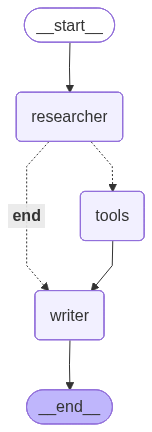

In [38]:
workflow = StateGraph(MessagesState)

workflow.add_node("researcher",researcher_agent)
workflow.add_node("writer",writer_agent)
workflow.add_node("tools",execute_tools)

workflow.add_edge(START,"researcher")
workflow.add_edge("researcher","writer")
workflow.add_conditional_edges("researcher",tools_condition,{"tools":"tools","__end__":"writer"})
workflow.add_edge("tools","writer")
workflow.add_edge("writer",END)

graph = workflow.compile()

from IPython.display import display, Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [39]:
res = graph.invoke({
    "messages":"Research the usecase of agentic ai in business"
})

In [40]:
res

{'messages': [HumanMessage(content='Research the usecase of agentic ai in business', additional_kwargs={}, response_metadata={}, id='78460ac5-bf7b-42d0-aca1-b410b0e3975b'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'j03g51b8z', 'function': {'arguments': '{"query":"agentic AI in business use cases"}', 'name': 'search_web'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 282, 'total_tokens': 302, 'completion_time': 0.070568364, 'completion_tokens_details': None, 'prompt_time': 0.014621455, 'prompt_tokens_details': None, 'queue_time': 0.050307165, 'total_time': 0.085189819}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e99a7-ec74-7573-b2a1-99ff2a55037a-0', tool_calls=[{'name': 'search_web', 'args': {'query': 'agentic AI in business use cases'}, 'id': 'j03g51b8z'